# Modele Baseline — Analyse de Sentiment Bancaire
**Objectif :** Construire un premier modele de classification TF-IDF + ML.

In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

# Modeles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Split
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
print("Bibliotheques importees !")

Bibliotheques importees !


In [4]:
# Chargement du dataset nettoye
df = pd.read_csv(
    r'C:\Users\emman\Documents\Portfolio\sentiment-analysis-banking\data\data_cleaned.csv'
)

print(f"Dataset charge : {len(df)} lignes")
print(f"Colonnes : {list(df.columns)}")

Dataset charge : 5841 lignes
Colonnes : ['Sentence', 'Sentiment', 'cleaned_text', 'label']


In [5]:
# Separation X et y
X = df['cleaned_text']
y = df['label']

# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train : {len(X_train)} lignes")
print(f"Test  : {len(X_test)} lignes")

# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=5000,   # garder les 5000 mots les plus importants
    ngram_range=(1, 2),  # mots simples et paires de mots
    min_df=2             # ignorer les mots qui apparaissent moins de 2 fois
)

# Apprendre sur le train et transformer
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"\nDimensions apres TF-IDF :")
print(f"Train : {X_train_tfidf.shape}")
print(f"Test  : {X_test_tfidf.shape}")

Train : 4672 lignes
Test  : 1169 lignes

Dimensions apres TF-IDF :
Train : (4672, 5000)
Test  : (1169, 5000)


In [6]:
# Entrainement de 3 modeles baseline
modeles = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'SVM': SVC(
        kernel='linear',
        random_state=42,
        probability=True
    )
}

resultats = {}

for nom, modele in modeles.items():
    print(f"Entrainement : {nom}...")
    modele.fit(X_train_tfidf, y_train)
    y_pred = modele.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    resultats[nom] = {
        'modele': modele,
        'y_pred': y_pred,
        'accuracy': acc
    }
    print(f"Accuracy : {acc:.4f}\n")

print("Tous les modeles sont entraines !")

Entrainement : Logistic Regression...
Accuracy : 0.6980

Entrainement : Random Forest...
Accuracy : 0.6433

Entrainement : SVM...
Accuracy : 0.6989

Tous les modeles sont entraines !


In [8]:
# Rapport detaille pour chaque modele
label_names = ['negative', 'neutral', 'positive']

for nom, res in resultats.items():
    print("=" * 55)
    print(f"MODELE : {nom}")
    print("=" * 55)
    print(classification_report(
        y_test,
        res['y_pred'],
        target_names=label_names
    ))

MODELE : Logistic Regression
              precision    recall  f1-score   support

    negative       0.41      0.14      0.21       172
     neutral       0.69      0.89      0.78       626
    positive       0.77      0.63      0.69       371

    accuracy                           0.70      1169
   macro avg       0.62      0.55      0.56      1169
weighted avg       0.68      0.70      0.67      1169

MODELE : Random Forest
              precision    recall  f1-score   support

    negative       0.19      0.14      0.16       172
     neutral       0.67      0.79      0.73       626
    positive       0.76      0.63      0.69       371

    accuracy                           0.64      1169
   macro avg       0.54      0.52      0.53      1169
weighted avg       0.63      0.64      0.63      1169

MODELE : SVM
              precision    recall  f1-score   support

    negative       0.35      0.12      0.18       172
     neutral       0.70      0.88      0.78       626
    positi

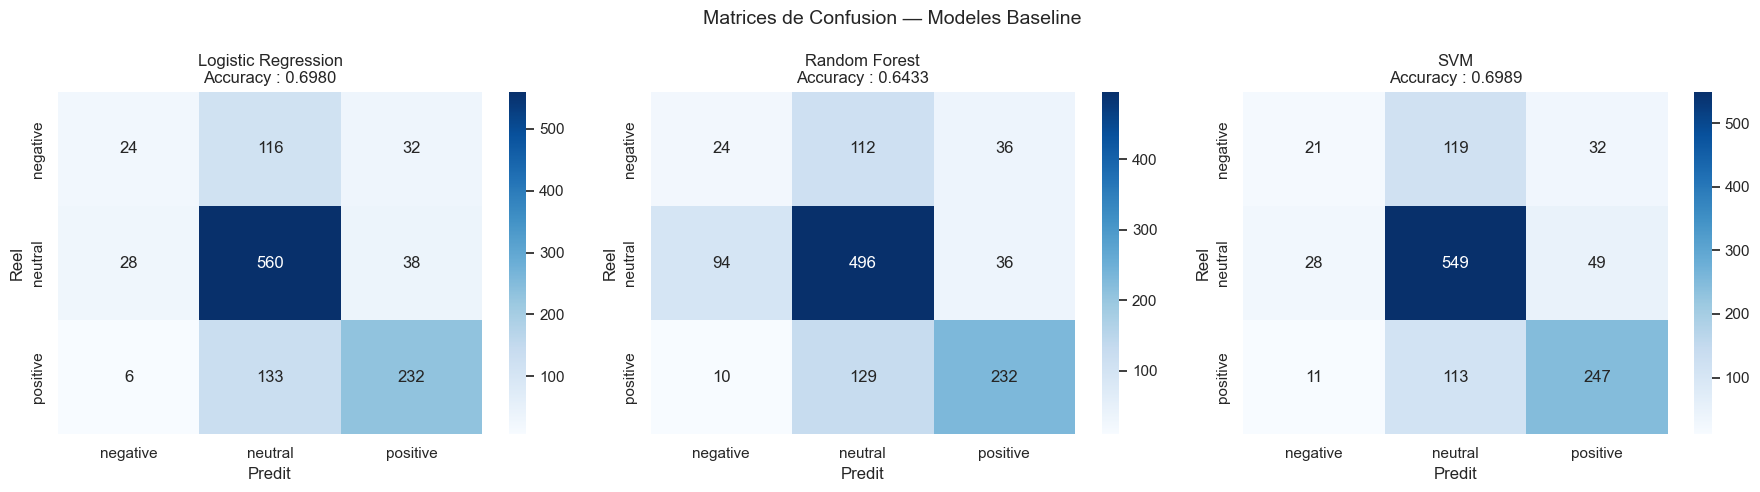

Graphique sauvegarde !


In [9]:
# Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nom, res) in zip(axes, resultats.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=label_names,
        yticklabels=label_names
    )
    ax.set_title(f"{nom}\nAccuracy : {res['accuracy']:.4f}")
    ax.set_ylabel('Reel')
    ax.set_xlabel('Predit')

plt.suptitle(
    'Matrices de Confusion — Modeles Baseline',
    fontsize=14
)
plt.tight_layout()
plt.savefig(
    '../reports/04_confusion_matrices_baseline.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Graphique sauvegarde !")

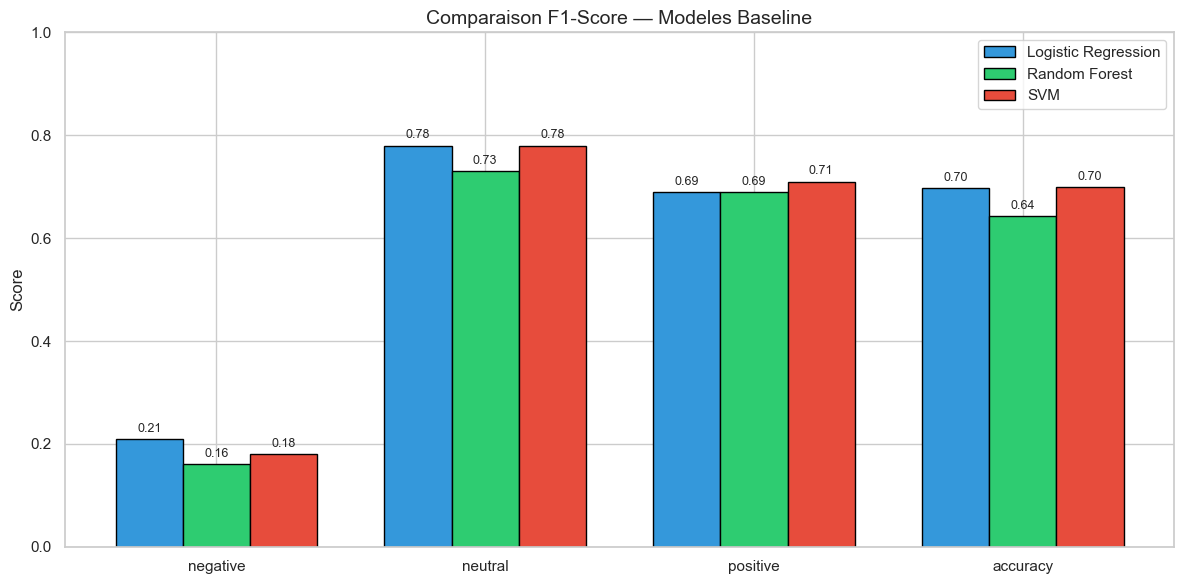

Graphique sauvegarde !


In [10]:
# Comparaison visuelle des modeles baseline
categories = ['negative', 'neutral', 'positive', 'accuracy']

lr_scores  = [0.21, 0.78, 0.69, 0.698]
rf_scores  = [0.16, 0.73, 0.69, 0.643]
svm_scores = [0.18, 0.78, 0.71, 0.699]

x     = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width, lr_scores,  width,
       label='Logistic Regression',
       color='#3498db', edgecolor='black')
ax.bar(x,          rf_scores,  width,
       label='Random Forest',
       color='#2ecc71', edgecolor='black')
ax.bar(x + width,  svm_scores, width,
       label='SVM',
       color='#e74c3c', edgecolor='black')

ax.set_title(
    'Comparaison F1-Score — Modeles Baseline',
    fontsize=14
)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.legend()

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig(
    '../reports/05_comparaison_baseline.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Graphique sauvegarde !")